In [24]:
import numpy as np #Numerical operations, arrays, and matrices
import pandas as pd #Data manipulation
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from data_preprocessing_module import *
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [11]:
df=pd.read_csv('datasets/changed/data_news_1.csv')
print(df.columns)
null_rows = df[df.isnull().any(axis=1)]
print(null_rows)
df['source'] = df['source'].fillna('Unknown')

Index(['type_of_news', 'title', 'text', 'source'], dtype='object')
    type_of_news                                              title  \
105         Fake  Hillary Denies She and Obama Founded ISIS…Then...   
112         Fake  CNN’s Post-Debate Rigged Poll Busted…Here Are ...   
114         Fake  Homosexual Thinks Muslims Will Accept Him, Ins...   
115         Fake  REVEALED! Minnesota Mall Attacker ID'd As One ...   
118         Fake  BREAKING: WikiLeaks Releases Proof Hillary Lie...   
138         Fake  ALERT: Police Pull Over ‘Islamic Refugee,’ Hor...   
139         Fake  CNN’s Post-Debate Rigged Poll Busted…Here Are ...   
149         Fake  Surgeon General warns: Drinking every time Tru...   

                                                  text source  
105  It was late one night in the White House when ...    NaN  
112  We’re shocked — SHOCKED — to learn that CNN’s ...    NaN  
114  Once again, the “religion of peace” has proven...    NaN  
115  A man wearing a security uniform

Accuracy: 0.6486486486486487
Classification Report:
               precision    recall  f1-score   support

        Fake       0.67      0.63      0.65        19
        Real       0.63      0.67      0.65        18

    accuracy                           0.65        37
   macro avg       0.65      0.65      0.65        37
weighted avg       0.65      0.65      0.65        37



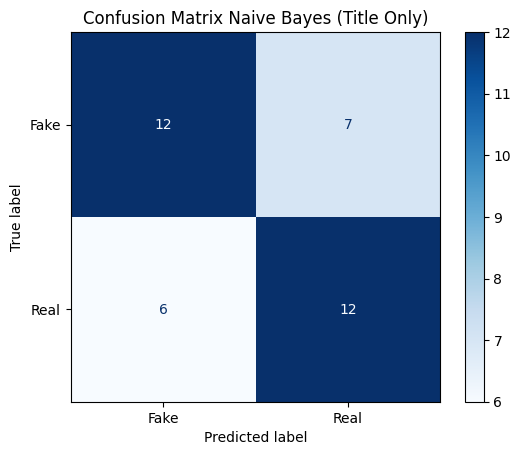

In [29]:
# Step 1: Combine and preprocess
df['title_clean'] = df['title'].apply(preprocess_text)

# Step 2: Vectorize cleaned text using TF-IDF
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['title_clean'])
y = df['type_of_news']

# Step 3: Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 4: Train Naive Bayes
nb_model_title = MultinomialNB()
nb_model_title.fit(X_train, y_train)

# Step 5: Evaluate
y_pred = nb_model_title.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, zero_division=0))


# Step 6: Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=['Fake', 'Real'])

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fake', 'Real'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix Naive Bayes (Title Only)")
plt.show()


Accuracy: 0.8108108108108109
Classification Report:
               precision    recall  f1-score   support

        Fake       0.88      0.74      0.80        19
        Real       0.76      0.89      0.82        18

    accuracy                           0.81        37
   macro avg       0.82      0.81      0.81        37
weighted avg       0.82      0.81      0.81        37



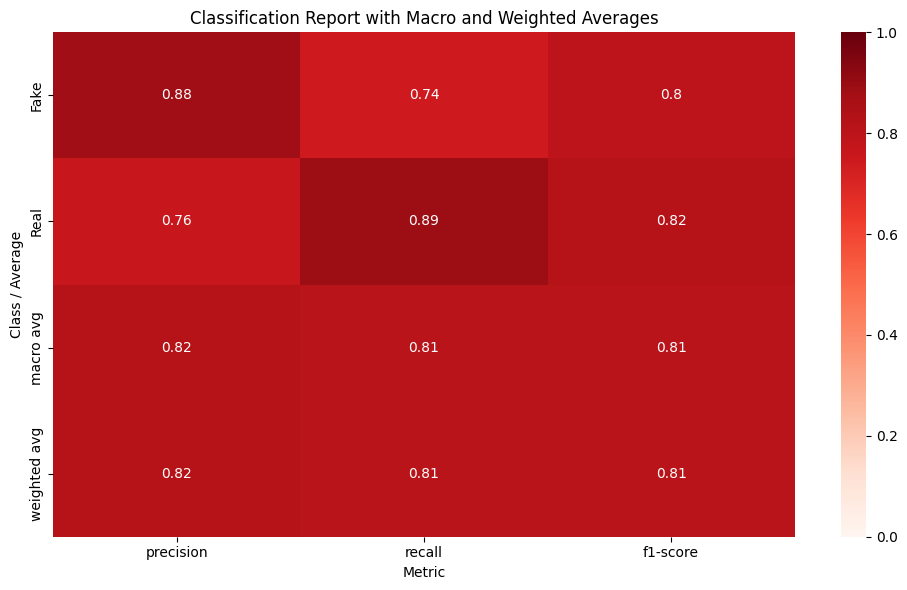

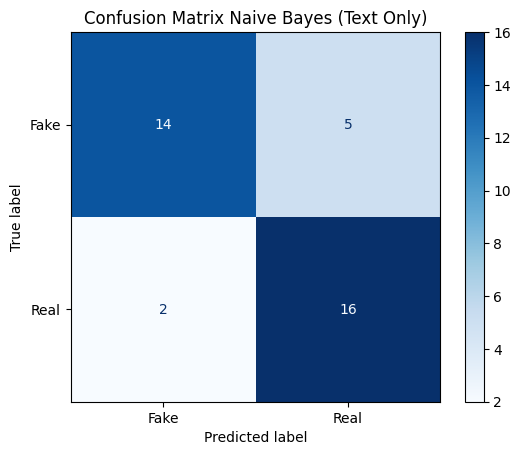

In [30]:
# Step 1: Combine and preprocess
df['text_clean'] = df['text'].apply(preprocess_text)

X = vectorizer.fit_transform(df['text_clean'])
y = df['type_of_news']

# Step 3: Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 4: Train Naive Bayes
nb_model_text = MultinomialNB()
nb_model_text.fit(X_train, y_train)

# Step 5: Evaluate
y_pred = nb_model_text.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, zero_division=0))


# Get classification report as a dictionary
report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

# Convert to DataFrame and round values
report_df = pd.DataFrame(report_dict).transpose()
report_df = report_df[['precision', 'recall', 'f1-score']].round(2)

# Reorder rows: classes first, then macro/weighted
row_order = [label for label in report_dict.keys() if label in ['Fake', 'Real']]
row_order += ['macro avg', 'weighted avg']

# Slice and reorder
plot_df = report_df.loc[row_order]

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(plot_df, annot=True, cmap='Reds', cbar=True, vmin=0, vmax=1)
plt.title('Classification Report with Macro and Weighted Averages')
plt.xlabel('Metric')
plt.ylabel('Class / Average')
plt.tight_layout()
plt.show()


# Step 6: Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=['Fake', 'Real'])

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fake', 'Real'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix Naive Bayes (Text Only)")
plt.show()


Columns name


In [22]:
user_title = input("Enter news title: ")
cleaned_title=preprocess_text(user_title)
user_vector = vectorizer.transform([cleaned_title])
prediction = nb_model_title.predict(user_vector)
print(prediction)

['Real']
